# 부산광역시 심야 버스 노선 신설 분석
**KAIA 2단계 - 시나리오2: 심야 노선 신설**

---

## 분석 목표
- 심야시간(0~5시) 대중교통 수요 파악
- 기존 심야 버스 노선의 서비스 커버리지 분석
- **기존 노선과 중복되지 않는 심야 버스 노선(안) 도출**

## 분석 흐름
```
STEP 1. 데이터 로드 및 전처리
STEP 2. 심야 수요 분석 (교통카드 기반)
STEP 3. 기존 심야 노선 서비스 커버리지 분석
STEP 4. 심야 서비스 공백 지역 도출
STEP 5. 공백 지역 수요 클러스터링 → 거점 도출
STEP 6. 거점 간 연결 → 신규 노선 후보 설계
STEP 7. 기존 노선 중복도 검증 → 최종 노선(안)
STEP 8. 시각화 및 결과 저장
```

> **주의:** 지하철은 참고용, 버스가 분석 메인

---
## STEP 1. 데이터 로드 및 전처리

In [8]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point, LineString
from shapely.ops import unary_union
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# === 경로 설정 (Windows PC) ===
BASE = r'C:\Users\HP\Desktop\작업 폴더\01.work\리버풀\데이터'
TARGET_CRS = 'EPSG:5179'

print('환경 설정 완료')

환경 설정 완료


In [9]:
# 1.1 버스노선 데이터
bus_routes = pd.read_csv(f'{BASE}/버스노선.csv', encoding='utf-8-sig')
bus_routes.columns = bus_routes.columns.str.strip().str.replace('\ufeff', '')
bus_routes['정류소ID_str'] = bus_routes['정류소ID'].astype(str).str.strip()

print(f'버스 노선: {bus_routes["노선번호"].nunique()}개, 정류소 행: {len(bus_routes):,}')

버스 노선: 326개, 정류소 행: 24,576


In [10]:
# 1.2 공간 데이터
bus_stops_shp = gpd.read_file(f'{BASE}/부산광역시_버스 정류소 정보(SHP)_20250121/tl_bus_station_info.shp')
if bus_stops_shp.crs.to_epsg() != 5179:
    bus_stops_shp = bus_stops_shp.to_crs(TARGET_CRS)
bus_stops_shp['bstopid_str'] = bus_stops_shp['bstopid'].astype(str).str.strip()

census = gpd.read_file(f'{BASE}/집계구경계/집계구경계.shp')
if census.crs.to_epsg() != 5179:
    census = census.to_crs(TARGET_CRS)
census['면적_km2'] = census.geometry.area / 1e6

print(f'버스 정류소: {len(bus_stops_shp):,}개')
print(f'집계구: {len(census):,}개')

버스 정류소: 8,522개
집계구: 6,802개


In [11]:
# 1.3 교통카드 거래내역
card_columns = [
    'date', 'card_type', 'card_number', 'seq', 'in_out',
    'transport_id', 'transport_name', 'station_id', 'station_name',
    'device_id', 'transaction_id', 'payment_type', 'time',
    'passenger_type', 'passenger_detail', 'passenger_count', 'station_seq'
]

card_df = pd.read_parquet(f'{BASE}/A001_202507/A001_202507_processed.parquet')

# 컬럼명 할당 (인덱스 컬럼 있으면 제거)
if len(card_df.columns) == 18:
    card_df = card_df.iloc[:, 1:]
if len(card_df.columns) == 17:
    card_df.columns = card_columns

# 파생변수
# in_out: 앞자리=환승횟수, 뒷자리=승하차 (0=승차, 1=하차)
card_df['환승횟수'] = card_df['in_out'].astype(str).str.split('-').str[0].astype(int)
card_df['승하차'] = card_df['in_out'].astype(str).str.split('-').str[1].map({'0':'승차','1':'하차'})

# 시간대
card_df['time_str'] = card_df['time'].astype(str).str.zfill(4)
card_df['시간대'] = card_df['time_str'].str[:2].astype(int)

# 수단 구분: transaction_id == '00000000' → 지하철, 그 외 → 버스
card_df['수단'] = card_df['transaction_id'].astype(str).str.strip().apply(
    lambda x: '지하철' if x in ('00000000', '0') else '버스'
)

print(f'교통카드: {len(card_df):,}건')
print(f'기간: {card_df["date"].min()} ~ {card_df["date"].max()}')
print(f'\n수단별:')
print(card_df['수단'].value_counts())

교통카드: 107,108,999건
기간: 2025-07-01 00:00:00 ~ 2025-07-31 00:00:00

수단별:
수단
지하철    53718856
버스     53390143
Name: count, dtype: int64


In [12]:
# 1.4 버스 데이터만 분리
bus_df = card_df[card_df['수단'] == '버스'].copy()
subway_df = card_df[card_df['수단'] == '지하철'].copy()

print(f'버스 거래: {len(bus_df):,}건 ({len(bus_df)/len(card_df)*100:.1f}%)')
print(f'지하철 거래: {len(subway_df):,}건 ({len(subway_df)/len(card_df)*100:.1f}%) ← 참고용')

# 버스 승하차 현황
bus_boarding = (bus_df['승하차']=='승차').sum()
bus_alighting = (bus_df['승하차']=='하차').sum()
print(f'\n버스 승차: {bus_boarding:,}, 하차: {bus_alighting:,}')
print(f'버스 하차 결측률: {(1-bus_alighting/bus_boarding)*100:.1f}%')

버스 거래: 53,390,143건 (49.8%)
지하철 거래: 53,718,856건 (50.2%) ← 참고용

버스 승차: 37,614,648, 하차: 15,775,495
버스 하차 결측률: 58.1%


---
## STEP 2. 심야 수요 분석

In [13]:
# 2.1 심야 버스 거래 추출
# 두 가지 기준:
# (A) 시간대 기반: 0~5시에 이용된 모든 버스
# (B) 노선명 기반: transport_name에 '심야' 포함

# (A) 시간대 기반 심야
night_bus_time = bus_df[bus_df['시간대'].between(0, 5)].copy()

# (B) 노선명 기반 심야 ('심야' 포함 노선의 전 시간대)
night_bus_name = bus_df[
    bus_df['transport_name'].astype(str).str.contains('심야', na=False)
].copy()

# 분석용은 (A) 시간대 기반 사용 (실제 심야 수요)
night_bus = night_bus_time.copy()

print(f'=== 심야 버스 현황 ===')
print(f'전체 버스: {len(bus_df):,}')
print(f'\n(A) 시간대(0~5시) 기반: {len(night_bus_time):,}건 ({len(night_bus_time)/len(bus_df)*100:.2f}%)')
print(f'(B) 노선명(심야) 기반: {len(night_bus_name):,}건 ({len(night_bus_name)/len(bus_df)*100:.2f}%)')

# 심야 시간대에 운행되는 노선 중 '심야' 이름 노선 vs 일반 노선
night_bus['심야노선여부'] = night_bus['transport_name'].astype(str).str.contains('심야', na=False)
print(f'\n심야 시간대(0~5시) 내 노선 구분:')
print(f'  심야 전용 노선: {night_bus["심야노선여부"].sum():,}건')
print(f'  일반 노선(새벽운행): {(~night_bus["심야노선여부"]).sum():,}건')

print(f'\n시간대별:')
print(night_bus.groupby(['시간대','승하차']).size().unstack(fill_value=0))

=== 심야 버스 현황 ===
전체 버스: 53,390,143

(A) 시간대(0~5시) 기반: 823,652건 (1.54%)
(B) 노선명(심야) 기반: 43,360건 (0.08%)

심야 시간대(0~5시) 내 노선 구분:
  심야 전용 노선: 27,217건
  일반 노선(새벽운행): 796,435건

시간대별:
승하차      승차      하차
시간대                
0     64284   32350
1      4842    2981
2       170     254
3         5       0
4     35754    2968
5    493132  186912


In [14]:
# 2.2 심야 버스 정류소별 승차량
night_boarding = night_bus[night_bus['승하차'] == '승차']

night_stop_demand = night_boarding.groupby(
    ['station_id', 'station_name']
).size().reset_index(name='심야승차량')
night_stop_demand = night_stop_demand.sort_values('심야승차량', ascending=False)

print(f'심야 승차 정류소: {len(night_stop_demand):,}개')
print(f'심야 총 승차: {night_stop_demand["심야승차량"].sum():,}건')
print(f'\n심야 승차량 상위 30:')
print(night_stop_demand.head(30).to_string(index=False))

심야 승차 정류소: 3,996개
심야 총 승차: 598,187건

심야 승차량 상위 30:
station_id   station_name  심야승차량
   2621935    서면역.롯데호텔백화점   5889
   2621886            부산역   5149
   2621887            부산역   3941
   2621684     서면역.서면지하상가   3686
   2621931    서면역.롯데호텔백화점   3656
   2621682     서면역.서면지하상가   3253
   2601501           반여3동   3249
   2601186        우암자유아파트   2805
   2604951        하단역환승센터   2565
   2601043         부산성모병원   2563
   2621875            남포동   2442
   2600925           구포시장   2205
   2601111     용호2동행정복지센터   2120
   2621932 부산진우체국.가야1치안센터   2119
   2621686           부전시장   2054
   2601502         수협장산지점   1960
   2621933            가야역   1934
   2644330            하단역   1843
   2621951            주례역   1837
   2621687           부전시장   1829
   2601590           반여2동   1820
   2600498        서구청.충무동   1806
   2621938 부산진우체국.가야1치안센터   1776
   2600486           영도구청   1651
   2601540          부암교차로   1641
   2621571           동래시장   1639
   2616206       일동미라주아파트   1527
   2621680          송상현광장

In [15]:
# 2.3 심야 버스 노선별 이용량
night_route_usage = night_boarding.groupby(
    ['transport_id', 'transport_name']
).size().reset_index(name='심야승차량')
night_route_usage = night_route_usage.sort_values('심야승차량', ascending=False)

# '심야' 표시
night_route_usage['심야전용'] = night_route_usage['transport_name'].astype(str).str.contains('심야', na=False)

print(f'심야 시간대 운행 버스 노선: {len(night_route_usage)}개')
print(f'  - 심야 전용(이름에 심야): {night_route_usage["심야전용"].sum()}개')
print(f'  - 일반 노선(새벽 운행): {(~night_route_usage["심야전용"]).sum()}개')
print(f'\n노선별 승차량 상위 20:')
print(night_route_usage.head(20).to_string(index=False))

심야 시간대 운행 버스 노선: 262개
  - 심야 전용(이름에 심야): 10개
  - 일반 노선(새벽 운행): 252개

노선별 승차량 상위 20:
transport_id transport_name  심야승차량  심야전용
    26028003             68  14838 False
    26007005             81  12781 False
    26020001             23  12736 False
    26033001             33  11749 False
    26004001          110-1  11639 False
    26030001            169  11517 False
    26016001            126  11005 False
    26021003             30  10776 False
    26024006             16  10426 False
    26019002             27  10381 False
    26006004            138  10159 False
    26021008            113   9657 False
    26015010             99   9212 False
    26021001              8   8761 False
    26020002             26   8423 False
    26005007          115-1   8385 False
    26006001             67   8253 False
    26027001             44   7796 False
    26006003          138-1   7794 False
    26014001             15   7701 False


In [16]:
# 2.4 심야 OD (기종점) 추출
# 동일 카드의 연속 승차(0)-하차(1)를 매칭

night_sorted = night_bus.sort_values(['card_number', 'date', 'seq'])

od_pairs = []
for card, grp in night_sorted.groupby('card_number'):
    rows = grp.to_dict('records')
    i = 0
    while i < len(rows) - 1:
        if rows[i]['승하차'] == '승차' and rows[i+1]['승하차'] == '하차':
            od_pairs.append({
                'O_id': str(rows[i]['station_id']).strip(),
                'O_name': rows[i]['station_name'],
                'D_id': str(rows[i+1]['station_id']).strip(),
                'D_name': rows[i+1]['station_name'],
                'route': rows[i]['transport_name'],
                'time': rows[i]['time'],
                '시간대': rows[i]['시간대']
            })
            i += 2
        else:
            i += 1

od_df = pd.DataFrame(od_pairs)
print(f'심야 버스 OD: {len(od_df):,}건')

if len(od_df) > 0:
    od_agg = od_df.groupby(['O_name','D_name']).size().reset_index(name='통행량')
    od_agg = od_agg.sort_values('통행량', ascending=False)
    print(f'고유 OD쌍: {len(od_agg):,}개')
    print(f'\n주요 OD 상위 20:')
    print(od_agg.head(20).to_string(index=False))

심야 버스 OD: 211,177건
고유 OD쌍: 31,106개

주요 OD 상위 20:
    O_name          D_name  통행량
     엘지아파트           연산교차로  380
    성곡시장입구          부전시장입구  338
    부산성모병원         경성대학교입구  327
     부암교차로          부전시장입구  324
     우성아파트           연산교차로  305
  LG디스커버리랩          부전시장입구  292
   개금주공아파트  부산진우체국.가야1치안센터  285
용호2동행정복지센터         경성대학교입구  275
     현대아파트           연산교차로  270
  국제프라자아파트  부산진우체국.가야1치안센터  259
  만덕3주공아파트           덕천교차로  251
     용호사거리         경성대학교입구  248
   망미주공아파트           연산교차로  239
서면역.서면지하상가             부산역  235
     화인아파트  부산진우체국.가야1치안센터  203
      연동시장           연산교차로  200
      반여2동       동래역.내성교차로  196
      남산정역             덕천역  194
     삼광사입구          부전시장입구  194
    서3치안센터 부곡4동행정복지센터.온천장역  193


---
## STEP 3. 기존 심야 노선 서비스 커버리지

In [17]:
# 3.1 기존 심야 버스 노선 식별
# 교통카드 transport_name에 '심야'가 포함된 노선 = 심야 버스

# (1) 교통카드에서 심야 노선 추출 (transport_name에 '심야' 포함)
card_night_routes = card_df[
    (card_df['수단'] == '버스') & 
    (card_df['transport_name'].astype(str).str.contains('심야', na=False))
]['transport_name'].unique().tolist()

# (2) 버스노선.xlsx에서도 심야 노선 확인
route_night_names = bus_routes[
    bus_routes['노선번호'].astype(str).str.contains('심야', na=False)
]['노선번호'].unique().tolist()

existing_night_routes = sorted(set(card_night_routes + route_night_names))

print(f'=== 기존 심야 버스 노선 ===')
print(f'교통카드 기반 (transport_name에 심야 포함): {len(card_night_routes)}개')
print(f'  → {card_night_routes}')
print(f'\n버스노선.xlsx 기반 (노선번호에 심야 포함): {len(route_night_names)}개')
print(f'  → {route_night_names}')
print(f'\n합계 (중복제거): {len(existing_night_routes)}개')
print(f'  → {existing_night_routes}')

=== 기존 심야 버스 노선 ===
교통카드 기반 (transport_name에 심야 포함): 10개
  → ['1001(심야)', '182(심야)', '1002(심야)', '1000(심야)', '141(심야)', '183(심야)', '1003(심야)', '58-1(심야)', '2(심야)', '1004(심야)']

버스노선.xlsx 기반 (노선번호에 심야 포함): 15개
  → ['1001(심야)', '1002(심야)', '1003(심야)', '1004(심야)', '106(심야)', '141(심야)', '15(심야)', '183(심야)', '2(심야)', '30(심야)', '3008(심야)', '508(심야)', '51(심야)', '58-1(심야)', '58-2(심야)']

합계 (중복제거): 17개
  → ['1000(심야)', '1001(심야)', '1002(심야)', '1003(심야)', '1004(심야)', '106(심야)', '141(심야)', '15(심야)', '182(심야)', '183(심야)', '2(심야)', '30(심야)', '3008(심야)', '508(심야)', '51(심야)', '58-1(심야)', '58-2(심야)']


In [18]:
# 3.2 기존 심야 노선이 지나는 정류소 → 서비스 영역
night_route_stops = bus_routes[bus_routes['노선번호'].isin(existing_night_routes)]
night_stop_ids = set(night_route_stops['정류소ID_str'].unique())

# SHP 매핑
night_stops_gdf = bus_stops_shp[bus_stops_shp['bstopid_str'].isin(night_stop_ids)]
print(f'기존 심야 노선 정류소: {len(night_stop_ids)}개 (SHP 매핑: {len(night_stops_gdf)}개)')

# 400m 버퍼 서비스 영역
if len(night_stops_gdf) > 0:
    night_service = unary_union(night_stops_gdf.geometry.buffer(400))
    busan_area = unary_union(census.geometry)
    print(f'심야 서비스 커버리지: {night_service.area / busan_area.area * 100:.1f}%')
else:
    night_service = None
    print('심야 정류소 매핑 실패')

기존 심야 노선 정류소: 1374개 (SHP 매핑: 0개)
심야 정류소 매핑 실패


In [19]:
# 3.3 집계구별 심야 서비스 상태
if night_service is not None:
    census['심야커버리지'] = census.geometry.apply(
        lambda g: min(g.intersection(night_service).area / g.area, 1.0) if g.area > 0 else 0
    )
else:
    census['심야커버리지'] = 0.0

print(f'심야 커버리지 통계:')
print(census['심야커버리지'].describe().round(3))
print(f'\n커버리지 0% 집계구: {(census["심야커버리지"]==0).sum():,}개')
print(f'커버리지 50%+ 집계구: {(census["심야커버리지"]>=0.5).sum():,}개')

심야 커버리지 통계:
count    6802.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: 심야커버리지, dtype: float64

커버리지 0% 집계구: 6,802개
커버리지 50%+ 집계구: 0개


---
## STEP 4. 심야 서비스 공백 지역 도출

In [28]:
# 4.1 심야 승차 정류소 → 집계구 매핑 → 심야수요
# 정류소명 기반 매핑 (ID 불일치 문제 해결)
night_stop_demand['name_clean'] = night_stop_demand['station_name'].str.strip().str.replace(r'\s+', '', regex=True)
bus_stops_shp['name_clean'] = bus_stops_shp['bstopnm'].str.strip().str.replace(r'\s+', '', regex=True)

# 중복 정류소명 제거 (같은 이름 = 반대 방향 → 첫 번째만 사용)
bus_stops_unique = bus_stops_shp.drop_duplicates(subset='name_clean', keep='first')
print(f'버스정류소: 전체 {len(bus_stops_shp)}개 → unique {len(bus_stops_unique)}개')

# 정류소 SHP과 매핑
demand_with_geo = night_stop_demand.merge(
    bus_stops_unique[['name_clean','geometry','bstopid','bstopnm']],
    left_on='name_clean', right_on='name_clean', how='inner'
)
demand_gdf = gpd.GeoDataFrame(demand_with_geo, geometry='geometry', crs=TARGET_CRS)
print(f'공간 매핑 성공: {len(demand_gdf)}/{len(night_stop_demand)} ({len(demand_gdf)/len(night_stop_demand)*100:.1f}%)')

if len(demand_gdf) > 0:
    # 집계구별 심야수요 집계
    demand_in_census = gpd.sjoin(demand_gdf, census[['TOT_REG_CD','geometry']], how='left', predicate='within')
    census_night = demand_in_census.groupby('TOT_REG_CD')['심야승차량'].sum().reset_index(name='심야수요')

    # 기존 심야수요 컬럼 제거 후 병합
    if '심야수요' in census.columns:
        census = census.drop(columns=['심야수요'])
    census = census.merge(census_night, on='TOT_REG_CD', how='left')
    census['심야수요'] = census['심야수요'].fillna(0).astype(int)

    print(f'심야수요 있는 집계구: {(census["심야수요"]>0).sum():,}개')
    print(f'총 심야수요: {census["심야수요"].sum():,}건')
else:
    census['심야수요'] = 0
    print('⚠️ 매핑 실패: 심야수요 0으로 설정')

버스정류소: 전체 8522개 → unique 3954개
공간 매핑 성공: 3499/3996 (87.6%)
심야수요 있는 집계구: 1,301개
총 심야수요: 519,671건


In [29]:
# 4.2 공백 지역 = 심야수요 있는데 기존 심야 서비스 부족
gap = census[
    (census['심야수요'] > 0) &
    (census['심야커버리지'] < 0.3)  # 30% 미만
].copy()

print(f'=== 심야 서비스 공백 지역 ===')
print(f'조건: 심야수요 > 0 AND 심야커버리지 < 30%')
print(f'해당 집계구: {len(gap):,}개')
print(f'공백 지역 총 심야수요: {gap["심야수요"].sum():,}건')
print(f'\n상위 20:')
print(gap.nlargest(20, '심야수요')[['TOT_REG_CD','심야수요','심야커버리지','면적_km2']].to_string(index=False))

=== 심야 서비스 공백 지역 ===
조건: 심야수요 > 0 AND 심야커버리지 < 30%
해당 집계구: 1,301개
공백 지역 총 심야수요: 519,671건

상위 20:
    TOT_REG_CD  심야수요  심야커버리지   면적_km2
21050520010001 10665     0.0 0.177574
21030520010007  9096     0.0 0.037279
21010580010001  6082     0.0 0.084581
21050820030004  3905     0.0 0.059470
21070690010007  3845     0.0 0.204539
21070710010003  3690     0.0 0.534310
21080510020005  3640     0.0 0.042209
21140580020004  3635     0.0 0.028822
21030570010002  3581     0.0 0.061219
21080570010004  3424     0.0 0.053853
21070580010002  3359     0.0 0.641088
21090590010002  3305     0.0 0.024028
21050840020002  2870     0.0 0.020373
21150570040003  2643     0.0 0.149375
21130580010006  2628     0.0 0.070467
21050820010102  2619     0.0 0.016934
21070590010002  2610     0.0 0.019294
21050770020005  2533     0.0 0.041743
21090730020017  2493     0.0 0.046462
21050770010004  2476     0.0 0.060111


---
## STEP 5. 수요 클러스터링 → 거점 도출

In [30]:
# 5.1 공백 지역 집계구 중심점 기반 클러스터링
gap['cx'] = gap.geometry.centroid.x
gap['cy'] = gap.geometry.centroid.y

coords = gap[['cx','cy']].values
weights = gap['심야수요'].values

# DBSCAN: 1km 반경, 최소 3개 집계구
db = DBSCAN(eps=1000, min_samples=3)
gap['cluster'] = db.fit_predict(coords, sample_weight=weights)

n_clusters = gap[gap['cluster'] >= 0]['cluster'].nunique()
print(f'클러스터 수: {n_clusters}개')
print(f'노이즈: {(gap["cluster"]==-1).sum()}개 집계구')

# 클러스터별 요약
cluster_summary = gap[gap['cluster']>=0].groupby('cluster').agg(
    집계구수=('TOT_REG_CD','count'),
    총심야수요=('심야수요','sum'),
    평균커버리지=('심야커버리지','mean')
).round(3)
print(f'\n클러스터별 요약:')
print(cluster_summary.to_string())

클러스터 수: 72개
노이즈: 8개 집계구

클러스터별 요약:
         집계구수   총심야수요  평균커버리지
cluster                      
0          24    5916     0.0
1           1     111     0.0
2           4     764     0.0
3           4      71     0.0
4          37    5548     0.0
5           1      19     0.0
6           1       4     0.0
7           1     206     0.0
8           1     810     0.0
9        1052  474374     0.0
10         36    3453     0.0
11          5    2374     0.0
12         13    4954     0.0
13          1     946     0.0
14          1    1035     0.0
15          1     682     0.0
16          1     564     0.0
17          1     244     0.0
18          1      44     0.0
19          1     163     0.0
20          1      18     0.0
21          7    1082     0.0
22          1      81     0.0
23          1       8     0.0
24          1      20     0.0
25          1      86     0.0
26          1      18     0.0
27          1       5     0.0
28          1      14     0.0
29          1      20     0.0
30   

In [31]:
# 5.2 클러스터별 가중 중심점 = 거점(Hub)
hubs = []
for cid in sorted(gap[gap['cluster']>=0]['cluster'].unique()):
    sub = gap[gap['cluster']==cid]
    w = sub['심야수요'].values
    hubs.append({
        'hub_id': cid,
        'x': np.average(sub['cx'].values, weights=w),
        'y': np.average(sub['cy'].values, weights=w),
        '집계구수': len(sub),
        '총수요': int(sub['심야수요'].sum())
    })

hubs_df = pd.DataFrame(hubs)
hubs_gdf = gpd.GeoDataFrame(
    hubs_df, geometry=gpd.points_from_xy(hubs_df['x'], hubs_df['y']), crs=TARGET_CRS
)

print(f'거점 {len(hubs_df)}개 도출:')
print(hubs_df.to_string(index=False))

거점 72개 도출:
 hub_id            x            y  집계구수    총수요
      0 1.134732e+06 1.674719e+06    24   5916
      1 1.120073e+06 1.675687e+06     1    111
      2 1.155375e+06 1.691157e+06     4    764
      3 1.159671e+06 1.701683e+06     4     71
      4 1.156258e+06 1.696323e+06    37   5548
      5 1.160844e+06 1.704368e+06     1     19
      6 1.149141e+06 1.702847e+06     1      4
      7 1.138142e+06 1.675179e+06     1    206
      8 1.144682e+06 1.674775e+06     1    810
      9 1.141799e+06 1.685428e+06  1052 474374
     10 1.128576e+06 1.678659e+06    36   3453
     11 1.154670e+06 1.689208e+06     5   2374
     12 1.150441e+06 1.693690e+06    13   4954
     13 1.149900e+06 1.695063e+06     1    946
     14 1.152274e+06 1.689651e+06     1   1035
     15 1.148606e+06 1.693441e+06     1    682
     16 1.150140e+06 1.688845e+06     1    564
     17 1.131195e+06 1.678563e+06     1    244
     18 1.145955e+06 1.701452e+06     1     44
     19 1.144611e+06 1.700819e+06     1    163
  

In [32]:
# 5.3 거점에 가장 가까운 기존 정류소 매핑 (실제 정차 가능 지점)
for i, hub in hubs_gdf.iterrows():
    dists = bus_stops_shp.geometry.distance(hub.geometry)
    nearest_idx = dists.idxmin()
    nearest = bus_stops_shp.loc[nearest_idx]
    hubs_df.loc[i, '최근접정류소'] = nearest['bstopnm']
    hubs_df.loc[i, '최근접정류소ID'] = nearest['bstopid']
    hubs_df.loc[i, '거리_m'] = dists[nearest_idx]

print('거점별 최근접 정류소:')
print(hubs_df[['hub_id','총수요','최근접정류소','거리_m']].to_string(index=False))

거점별 최근접 정류소:
 hub_id    총수요          최근접정류소        거리_m
      0   5916          다대초등학교  257.707237
      1    111             서율리  988.953670
      2    764          내리초등학교   67.577883
      3     71              칠암  221.311777
      4   5548           기장도서관   33.676287
      5     19          묘관음사입구  308.492992
      6      4              임기 2282.669434
      7    206         모지포마을입구  128.286329
      8    810             차고지  800.393221
      9 474374           서면1번가  102.474982
     10   3453          명원초등학교  134.620921
     11   2374            송정종점  261.750521
     12   4954              본동  306.875998
     13    946            윗반송역  984.836197
     14   1035        동해선신해운대역 1146.495617
     15    682          해운대수목원  454.924349
     16    564         세명그린아파트 1524.610202
     17    244              진동 1201.319439
     18     44          두구동 입구  178.275974
     19    163         금정공영차고지  729.431159
     20     18          산성공해마을  626.819607
     21   1082            신호농협   79.71516

---
## STEP 6. 거점 간 연결 → 노선 후보 설계

In [33]:
# 6.1 거점 간 후보 노선 생성
candidates = []

for (i, ha), (j, hb) in combinations(hubs_df.iterrows(), 2):
    dist = np.sqrt((ha['x']-hb['x'])**2 + (ha['y']-hb['y'])**2)
    demand = ha['총수요'] + hb['총수요']
    
    # 노선 경로 (직선)
    line = LineString([(ha['x'], ha['y']), (hb['x'], hb['y'])])
    
    # 기존 심야 노선 정류소와의 중복 (경로 500m 버퍼 내)
    buf = line.buffer(500)
    overlap = night_stops_gdf.geometry.within(buf).sum() if len(night_stops_gdf)>0 else 0
    
    # 경로 인근 전체 정류소 수 (활용 가능 인프라)
    all_nearby = bus_stops_shp.geometry.within(buf).sum()
    
    candidates.append({
        '출발': int(ha['hub_id']),
        '도착': int(hb['hub_id']),
        '출발정류소': ha['최근접정류소'],
        '도착정류소': hb['최근접정류소'],
        '거리_km': round(dist/1000, 1),
        '합산수요': int(demand),
        '기존심야중복': int(overlap),
        '인근정류소수': int(all_nearby),
        'geometry': line
    })

cand_df = pd.DataFrame(candidates)

# 점수: 수요효율(수요/거리) / 기존중복 페널티
cand_df['수요효율'] = cand_df['합산수요'] / cand_df['거리_km']
cand_df['노선점수'] = cand_df['수요효율'] / (1 + cand_df['기존심야중복'])
cand_df = cand_df.sort_values('노선점수', ascending=False).reset_index(drop=True)

print(f'=== 노선 후보 {len(cand_df)}개 ===')
print('점수 = (합산수요 / 거리km) / (1 + 기존심야중복)\n')
display_cols = ['출발','도착','출발정류소','도착정류소','거리_km','합산수요','기존심야중복','인근정류소수','노선점수']
print(cand_df[display_cols].round(1).to_string(index=False))

=== 노선 후보 2556개 ===
점수 = (합산수요 / 거리km) / (1 + 기존심야중복)

 출발  도착           출발정류소           도착정류소  거리_km   합산수요  기존심야중복  인근정류소수     노선점수
  9  67           서면1번가          어린이대공원    4.2 474570       0      96 112992.9
  9  65           서면1번가            경남고교    4.3 474382       0      65 110321.4
  9  66           서면1번가           구덕꽃마을    4.9 474573       0      62  96851.6
  9  51           서면1번가             약수터    5.5 474510       0     149  86274.5
  9  68           서면1번가          부산해군회관    7.8 477733       0     259  61247.8
  9  23           서면1번가             광명사    8.1 474382       0     301  58565.7
  9  70           서면1번가         산성터널영업소    9.0 475585       0     189  52842.8
  9  16           서면1번가         세명그린아파트    9.0 474938       0     214  52770.9
  9  26           서면1번가            등구마을    9.1 474392       0     135  52131.0
  9  20           서면1번가          산성공해마을    9.4 474392       0     194  50467.2
  9  24           서면1번가              작지    9.6 474394       0     289  49416

---
## STEP 7. 노선별 경유 정류소 도출

In [34]:
# 7.1 상위 노선에 대해 경유 정류소 추천
# 기존 심야 노선 정류소는 제외 → 중복 최소화

TOP_N = min(5, len(cand_df))

route_plans = []

for rank, (_, route) in enumerate(cand_df.head(TOP_N).iterrows(), 1):
    print(f'\n{"="*60}')
    print(f'[후보 {rank}] 거점{int(route["출발"])} ({route["출발정류소"]}) → 거점{int(route["도착"])} ({route["도착정류소"]})')
    print(f'거리: {route["거리_km"]}km | 수요: {int(route["합산수요"])}건 | 점수: {route["노선점수"]:.1f}')
    print(f'기존 심야 중복: {int(route["기존심야중복"])}개 정류소')
    
    # 경로 500m 버퍼 내 정류소
    buf = route['geometry'].buffer(500)
    nearby = bus_stops_shp[bus_stops_shp.geometry.within(buf)].copy()
    
    # 기존 심야 노선 정류소 제외
    new_stops = nearby[~nearby['bstopid_str'].isin(night_stop_ids)].copy()
    
    # 기점으로부터 거리순 정렬
    start_pt = Point(route['geometry'].coords[0])
    new_stops['기점거리_m'] = new_stops.geometry.distance(start_pt).round(0).astype(int)
    new_stops = new_stops.sort_values('기점거리_m')
    
    print(f'\n경유 후보 정류소: {len(new_stops)}개 (기존 심야 제외)')
    if len(new_stops) > 0:
        print(new_stops[['bstopid','bstopnm','기점거리_m']].to_string(index=False))
    
    route_plans.append({
        'rank': rank,
        'hub_from': int(route['출발']),
        'hub_to': int(route['도착']),
        'stops': new_stops[['bstopid','bstopnm','기점거리_m']].to_dict('records'),
        'n_stops': len(new_stops),
        'score': route['노선점수']
    })


[후보 1] 거점9 (서면1번가) → 거점67 (어린이대공원)
거리: 4.2km | 수요: 474570건 | 점수: 112992.9
기존 심야 중복: 0개 정류소

경유 후보 정류소: 96개 (기존 심야 제외)
  bstopid       bstopnm  기점거리_m
164670502         서면1번가     102
164650201         서면복개로     108
164670503         서면1번가     111
505880000          서면한전     227
164640301          서면시장     236
164520103         쥬디스태화     243
505860000    서면역.서면지하상가     253
164650302   롯데호텔백화점.서면역     268
164620301          네오스포     281
505850000    서면역.서면지하상가     288
505870000          서면한전     295
164650301   롯데호텔백화점.서면역     345
164670501       부산진초등학교     346
164710104          롯데호텔     351
164670504       부산진초등학교     354
164710102   롯데호텔백화점.서면역     362
164730201       더샵센트럴스타     364
164710101   롯데호텔백화점.서면역     376
164670301       부산진초등학교     384
164710103          롯데호텔     386
164630302   롯데호텔백화점.서면역     418
164630301   롯데호텔백화점.서면역     424
164680201           서면역     428
164630304   롯데호텔백화점.서면역     434
164670201       부산진초등학교     439
164670202       부산진초등학교     465
164600202        

In [35]:
# 7.2 기존 전체 노선과의 중복도 검증
# 심야 노선뿐만 아니라 전체 326개 노선과의 중복 확인

print('=== 전체 노선 대비 중복도 검증 ===')
for rank, (_, route) in enumerate(cand_df.head(TOP_N).iterrows(), 1):
    buf = route['geometry'].buffer(500)
    nearby_all = bus_stops_shp[bus_stops_shp.geometry.within(buf)]
    nearby_ids = set(nearby_all['bstopid_str'])
    
    # 이 정류소들을 지나는 기존 노선은?
    overlapping_routes = bus_routes[
        bus_routes['정류소ID_str'].isin(nearby_ids)
    ]['노선번호'].unique()
    
    # 그 중 심야 노선
    overlap_night = [r for r in overlapping_routes if r in existing_night_routes]
    overlap_day = [r for r in overlapping_routes if r not in existing_night_routes]
    
    print(f'\n[후보 {rank}] 거점{int(route["출발"])} → 거점{int(route["도착"])}')
    print(f'  경로 인근 기존 노선: {len(overlapping_routes)}개')
    print(f'    - 주간 노선: {len(overlap_day)}개')
    print(f'    - 심야 노선: {len(overlap_night)}개 → {overlap_night}')
    
    if len(overlap_night) == 0:
        print(f'  ✓ 기존 심야 노선과 중복 없음!')
    else:
        print(f'  △ 기존 심야 노선 {len(overlap_night)}개와 일부 중복')

=== 전체 노선 대비 중복도 검증 ===

[후보 1] 거점9 → 거점67
  경로 인근 기존 노선: 0개
    - 주간 노선: 0개
    - 심야 노선: 0개 → []
  ✓ 기존 심야 노선과 중복 없음!

[후보 2] 거점9 → 거점65
  경로 인근 기존 노선: 0개
    - 주간 노선: 0개
    - 심야 노선: 0개 → []
  ✓ 기존 심야 노선과 중복 없음!

[후보 3] 거점9 → 거점66
  경로 인근 기존 노선: 0개
    - 주간 노선: 0개
    - 심야 노선: 0개 → []
  ✓ 기존 심야 노선과 중복 없음!

[후보 4] 거점9 → 거점51
  경로 인근 기존 노선: 0개
    - 주간 노선: 0개
    - 심야 노선: 0개 → []
  ✓ 기존 심야 노선과 중복 없음!

[후보 5] 거점9 → 거점68
  경로 인근 기존 노선: 0개
    - 주간 노선: 0개
    - 심야 노선: 0개 → []
  ✓ 기존 심야 노선과 중복 없음!


---
## STEP 8. 시각화 및 결과 저장

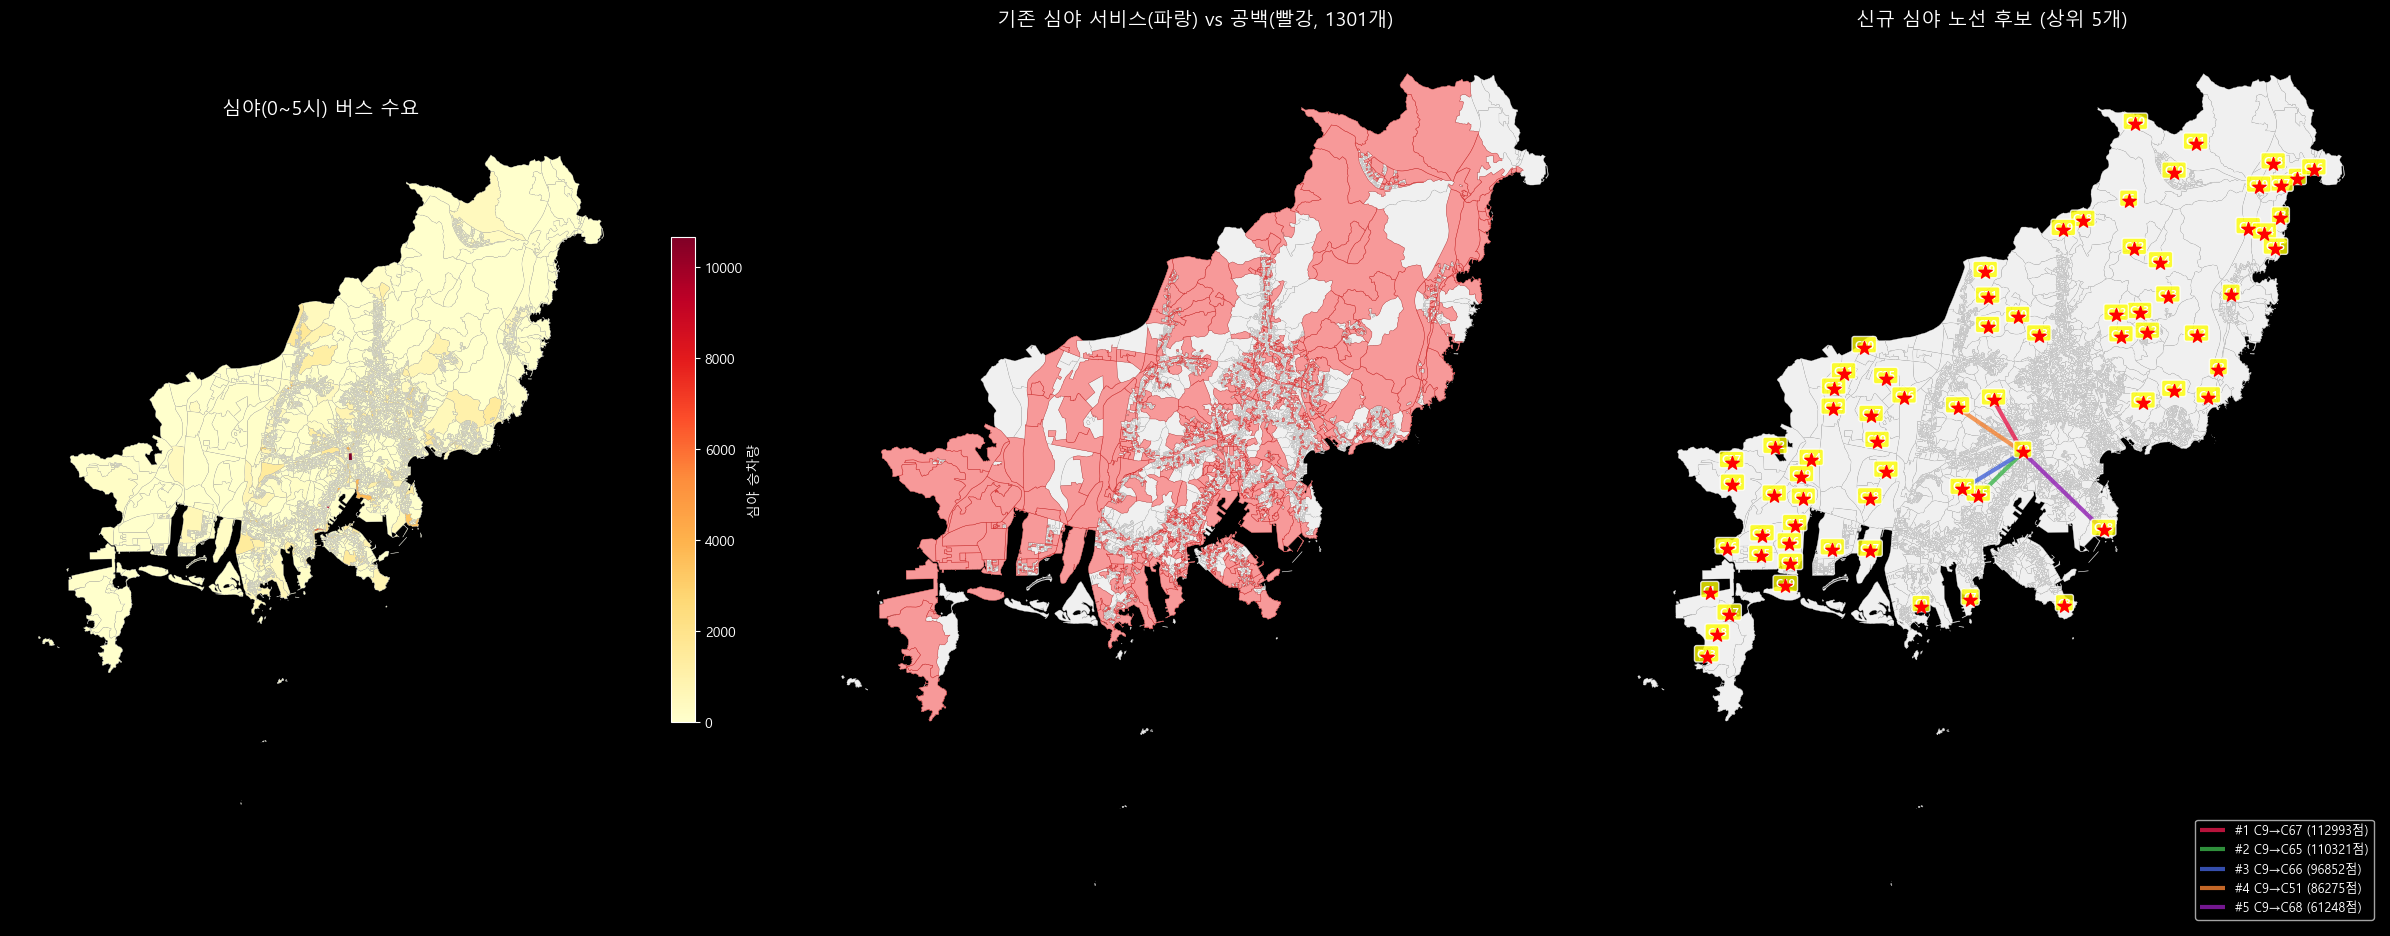

In [36]:
# 8.1 종합 시각화
fig, axes = plt.subplots(1, 3, figsize=(24, 10))

# --- (1) 심야 수요 분포 ---
census.plot(ax=axes[0], column='심야수요', cmap='YlOrRd', 
            edgecolor='#cccccc', linewidth=0.2, legend=True,
            legend_kwds={'shrink':0.5, 'label':'심야 승차량'})
axes[0].set_title('심야(0~5시) 버스 수요', fontsize=14)
axes[0].set_axis_off()

# --- (2) 기존 심야 서비스 + 공백 ---
census.plot(ax=axes[1], facecolor='#f0f0f0', edgecolor='#cccccc', linewidth=0.2)
if night_service is not None:
    gpd.GeoSeries([night_service], crs=TARGET_CRS).plot(
        ax=axes[1], facecolor='#3388ff', alpha=0.2, edgecolor='blue', linewidth=0.3
    )
if len(gap) > 0:
    gap.plot(ax=axes[1], facecolor='#ff4444', alpha=0.5, edgecolor='#cc0000', linewidth=0.3)
axes[1].set_title(f'기존 심야 서비스(파랑) vs 공백(빨강, {len(gap)}개)', fontsize=14)
axes[1].set_axis_off()

# --- (3) 신규 노선 후보 ---
census.plot(ax=axes[2], facecolor='#f0f0f0', edgecolor='#cccccc', linewidth=0.2)
if night_service is not None:
    gpd.GeoSeries([night_service], crs=TARGET_CRS).plot(
        ax=axes[2], facecolor='#3388ff', alpha=0.1
    )

colors = ['#e6194b', '#3cb44b', '#4363d8', '#f58231', '#911eb4']
for j, (_, r) in enumerate(cand_df.head(TOP_N).iterrows()):
    gpd.GeoSeries([r['geometry']], crs=TARGET_CRS).plot(
        ax=axes[2], color=colors[j%5], linewidth=3, alpha=0.8,
        label=f'#{j+1} C{int(r["출발"])}→C{int(r["도착"])} ({r["노선점수"]:.0f}점)'
    )

if len(hubs_gdf) > 0:
    hubs_gdf.plot(ax=axes[2], color='red', markersize=100, marker='*', zorder=5)
    for _, h in hubs_gdf.iterrows():
        axes[2].annotate(
            f'C{int(h["hub_id"])}', xy=(h.geometry.x, h.geometry.y),
            fontsize=8, ha='center', fontweight='bold',
            bbox=dict(facecolor='yellow', alpha=0.8, boxstyle='round,pad=0.2')
        )

axes[2].set_title(f'신규 심야 노선 후보 (상위 {TOP_N}개)', fontsize=14)
axes[2].legend(loc='lower right', fontsize=9)
axes[2].set_axis_off()

plt.tight_layout()
plt.savefig(f'{BASE}/fig_night_route_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

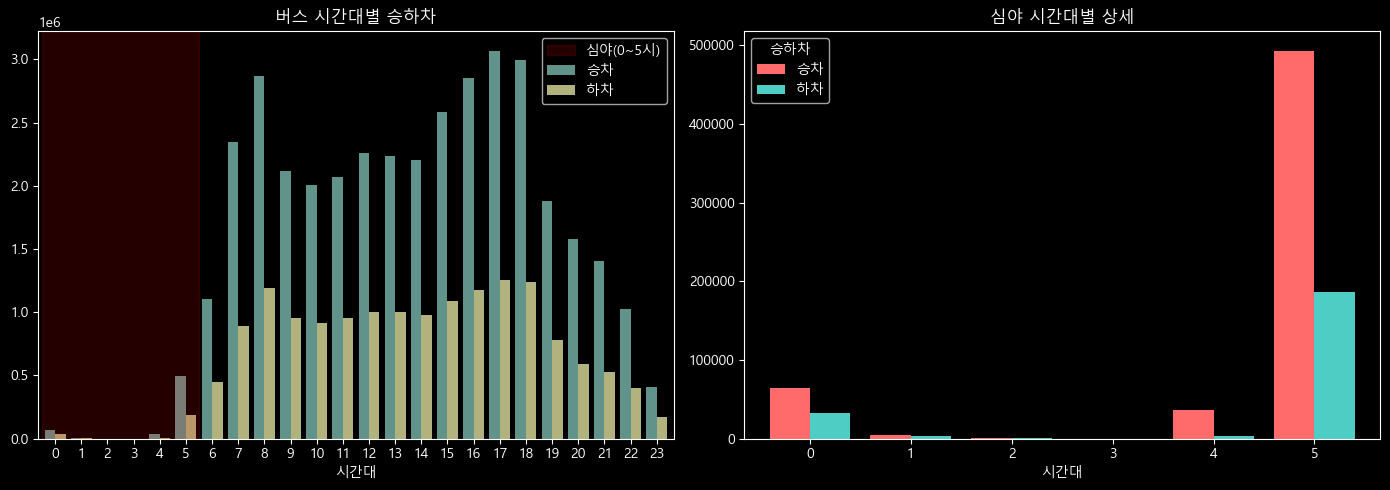

In [37]:
# 8.2 시간대별 심야 수요 차트
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 전체 시간대별 (심야 강조)
hourly = bus_df.groupby(['시간대','승하차']).size().unstack(fill_value=0)
hourly.plot(kind='bar', ax=axes[0], width=0.8, alpha=0.7)
# 심야 영역 강조
axes[0].axvspan(-0.5, 5.5, alpha=0.15, color='red', label='심야(0~5시)')
axes[0].set_title('버스 시간대별 승하차')
axes[0].set_xlabel('시간대')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=0)

# 심야 상세
night_hourly = night_bus.groupby(['시간대','승하차']).size().unstack(fill_value=0)
night_hourly.plot(kind='bar', ax=axes[1], width=0.8, color=['#ff6b6b','#4ecdc4'])
axes[1].set_title('심야 시간대별 상세')
axes[1].set_xlabel('시간대')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(f'{BASE}/fig_night_hourly.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
# 8.3 결과 저장
print('=== 결과 파일 저장 ===')

# (1) 심야 수요 거점
hubs_df.to_csv(f'{BASE}/result_심야_수요거점.csv', index=False, encoding='utf-8-sig')
print(f'  result_심야_수요거점.csv ({len(hubs_df)}개 거점)')

# (2) 심야 서비스 공백 지역
gap_save = gap[['TOT_REG_CD','심야수요','심야커버리지','면적_km2','cluster']].copy()
gap_save.to_csv(f'{BASE}/result_심야_서비스공백.csv', index=False, encoding='utf-8-sig')
print(f'  result_심야_서비스공백.csv ({len(gap)}개 집계구)')

# (3) 노선 후보 순위
save_cols = ['출발','도착','출발정류소','도착정류소','거리_km','합산수요','기존심야중복','인근정류소수','수요효율','노선점수']
cand_df[save_cols].to_csv(f'{BASE}/result_심야_노선후보.csv', index=False, encoding='utf-8-sig')
print(f'  result_심야_노선후보.csv ({len(cand_df)}개 후보)')

# (4) 심야 OD
if len(od_df) > 0:
    od_agg.to_csv(f'{BASE}/result_심야_OD.csv', index=False, encoding='utf-8-sig')
    print(f'  result_심야_OD.csv ({len(od_agg)}개 OD쌍)')

# (5) 집계구별 심야 현황
census[['TOT_REG_CD','ADM_CD','면적_km2','심야수요','심야커버리지']].to_csv(
    f'{BASE}/result_집계구_심야현황.csv', index=False, encoding='utf-8-sig'
)
print(f'  result_집계구_심야현황.csv ({len(census)}개 집계구)')

print('\n저장 완료!')

=== 결과 파일 저장 ===
  result_심야_수요거점.csv (72개 거점)
  result_심야_서비스공백.csv (1301개 집계구)
  result_심야_노선후보.csv (2556개 후보)
  result_심야_OD.csv (31106개 OD쌍)
  result_집계구_심야현황.csv (6802개 집계구)

저장 완료!


In [39]:
# 8.4 종합 요약
print('='*60)
print('심야 버스 노선 신설 분석 종합 요약')
print('='*60)

print(f'\n[데이터 현황]')
print(f'  교통카드 전체: {len(card_df):,}건')
print(f'  버스: {len(bus_df):,}건 | 지하철(참고): {len(subway_df):,}건')
print(f'  심야 버스: {len(night_bus):,}건 ({len(night_bus)/len(bus_df)*100:.2f}%)')

print(f'\n[기존 심야 서비스]')
print(f'  기존 심야 노선: {len(existing_night_routes)}개')
print(f'  심야 정류소: {len(night_stop_ids)}개')
if night_service:
    print(f'  서비스 커버리지: {night_service.area/busan_area.area*100:.1f}%')

print(f'\n[심야 서비스 공백]')
print(f'  공백 집계구: {len(gap)}개')
print(f'  공백 지역 심야수요: {gap["심야수요"].sum():,}건')

print(f'\n[신규 노선 제안]')
print(f'  수요 거점: {len(hubs_df)}개')
print(f'  노선 후보: {len(cand_df)}개')
for j, (_, r) in enumerate(cand_df.head(3).iterrows(), 1):
    print(f'  #{j}: {r["출발정류소"]} → {r["도착정류소"]} ({r["거리_km"]}km, 수요{int(r["합산수요"])}건, 중복{int(r["기존심야중복"])}개)')

심야 버스 노선 신설 분석 종합 요약

[데이터 현황]
  교통카드 전체: 107,108,999건
  버스: 53,390,143건 | 지하철(참고): 53,718,856건
  심야 버스: 823,652건 (1.54%)

[기존 심야 서비스]
  기존 심야 노선: 17개
  심야 정류소: 1374개

[심야 서비스 공백]
  공백 집계구: 1301개
  공백 지역 심야수요: 519,671건

[신규 노선 제안]
  수요 거점: 72개
  노선 후보: 2556개
  #1: 서면1번가 → 어린이대공원 (4.2km, 수요474570건, 중복0개)
  #2: 서면1번가 → 경남고교 (4.3km, 수요474382건, 중복0개)
  #3: 서면1번가 → 구덕꽃마을 (4.9km, 수요474573건, 중복0개)
